##Import Dataset and Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [2]:
fake_data = pd.read_csv('Fake.csv', engine='python', on_bad_lines='skip')
true_data = pd.read_csv('True.csv', engine='python', on_bad_lines='skip')

In [3]:
fake_data.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true_data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
true_data['label'] = 1
fake_data['label'] = 0

In [6]:
true_data.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [7]:
fake_data.shape, true_data.shape

((23481, 5), (21417, 5))

In [8]:
news = pd.concat([fake_data, true_data], axis= 0)

In [9]:
news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
news.tail()

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [11]:
news.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [12]:
news = news.drop(['title', 'subject', 'date'], axis = 1)

In [13]:
news

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
...,...,...
21412,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
21413,"LONDON (Reuters) - LexisNexis, a provider of l...",1
21414,MINSK (Reuters) - In the shadow of disused Sov...,1
21415,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [14]:
news = news.sample(frac = 1)

In [15]:
news.head()

,text,label
21810,The American taxpayers are on the hook for les...,0
9704,WASHINGTON (Reuters) - Democratic presidential...,1
18123,As James Bond s nemesis Auric Goldfinger famou...,0
7113,SANTIAGO (Reuters) - Countries involved in the...,1
17395,HONG KONG (Reuters) - The jailing of three Hon...,1


In [16]:
news = news.reset_index(drop = True)

In [17]:
news.head()

,text,label
0,The American taxpayers are on the hook for les...,0
1,WASHINGTON (Reuters) - Democratic presidential...,1
2,As James Bond s nemesis Auric Goldfinger famou...,0
3,SANTIAGO (Reuters) - Countries involved in the...,1
4,HONG KONG (Reuters) - The jailing of three Hon...,1


In [18]:
import re # Regular Expression module to convert text to reading form or easy to read

In [19]:
def wordopt(text):
    # convert into lowercase
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    # Remove URLs
    text = re.sub('https?://\S+|www\.\S+', '', text)
    # remove HTML tages
    text = re.sub('<.*?>+', '', text)
    # Remove punctuation
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    # remove newline character
    text = re.sub('\n', '', text)
    # Remove words with digits
    text = re.sub('\w*\d\w*', '', text)
    return text

In [20]:
news['text'] = news['text'].apply(wordopt)

In [21]:
news['text']

,text
0,the american taxpayers are on the hook for les...
1,washington reuters democratic presidential...
2,as james bond s nemesis auric goldfinger famou...
3,santiago reuters countries involved in the...
4,hong kong reuters the jailing of three hon...
...,...
44893,https www youtube com watch timecontinue v
44894,gothenburg reuters british prime minister ...
44895,beijing reuters china s former ambassador ...
44896,century wire says it s halloween and hillar...


#Splitting the data

In [22]:
X = news['text']
Y = news['label']

In [23]:
print(X)

0        the american taxpayers are on the hook for les...
1        washington  reuters    democratic presidential...
2        as james bond s nemesis auric goldfinger famou...
3        santiago  reuters    countries involved in the...
4        hong kong  reuters    the jailing of three hon...
                               ...                        
44893      https   www youtube com watch timecontinue  v  
44894    gothenburg  reuters    british prime minister ...
44895    beijing  reuters    china s former ambassador ...
44896     century wire says it s halloween   and hillar...
44897    the eldest son of ex alaska gov  sarah palin b...
Name: text, Length: 44898, dtype: object


In [24]:
print(Y)

0        0
1        1
2        0
3        1
4        1
        ..
44893    0
44894    1
44895    1
44896    0
44897    0
Name: label, Length: 44898, dtype: int64


In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [26]:
print(X.shape, X_train.shape, X_test.shape)

(44898,) (35918,) (8980,)


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()

In [28]:
xv_train = vectorization.fit_transform(X_train)
xv_test = vectorization.transform(X_test)

#Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

In [30]:
LR.fit(xv_train, Y_train)

LogisticRegression()

In [31]:
pred_lr = LR.predict(xv_test)

In [66]:
LR_score = LR.score(xv_train, Y_train)
print(f"Training Score (Accuracy): {LR_score:}")

Training Score (Accuracy): 0.9912300239434267


In [32]:
LR.score(xv_test, Y_test)

0.9864142538975501

##Logistic Regression Report

In [58]:
print('Logistic Regression:')
print(classification_report(Y_test, pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



#Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier()

In [35]:
DTC.fit(xv_train, Y_train)

DecisionTreeClassifier()

In [36]:
pred_DTC = DTC.predict(xv_test)

In [68]:
DTC_score = DTC.score(xv_train, Y_train)
print(f"Training Score (Accuracy): {DTC_score:}")

Training Score (Accuracy): 0.9999721588061696


In [37]:
DTC.score(xv_test, Y_test)

0.9968819599109131

##Decision Tree Classifier Report

In [57]:
print('Decision Tree:')
print(classification_report(Y_test, pred_DTC))

Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



#Random Forest Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [40]:
rfc.fit(xv_train, Y_train)

RandomForestClassifier()

In [43]:
pred_rfc = rfc.predict(xv_test)

In [69]:
rfc_score = rfc.score(xv_train, Y_train)
print(f"Training Score (Accuracy): {rfc_score:}")

Training Score (Accuracy): 0.9999721588061696


In [44]:
rfc.score(xv_test, Y_test)

0.9927616926503341

##Random Forest Classifier Report

In [59]:
print('Random Forest:')
print(classification_report(Y_test, pred_rfc))

Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



##Conclusion

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame with model performance
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Train Accuracy (%)': [0.9912300239434267,  0.9999721588061696, 0.9999721588061696],
    'Test Accuracy (%)': [0.9864142538975501, 0.9968819599109131, 0.9927616926503341]
}

df = pd.DataFrame(data)
print("Accuracy of All models used\n")
print(df)


Accuracy of All models used

                 Model  Train Accuracy (%)  Test Accuracy (%)
0  Logistic Regression            0.991230           0.986414
1        Decision Tree            0.999972           0.996882
2        Random Forest            0.999972           0.992762


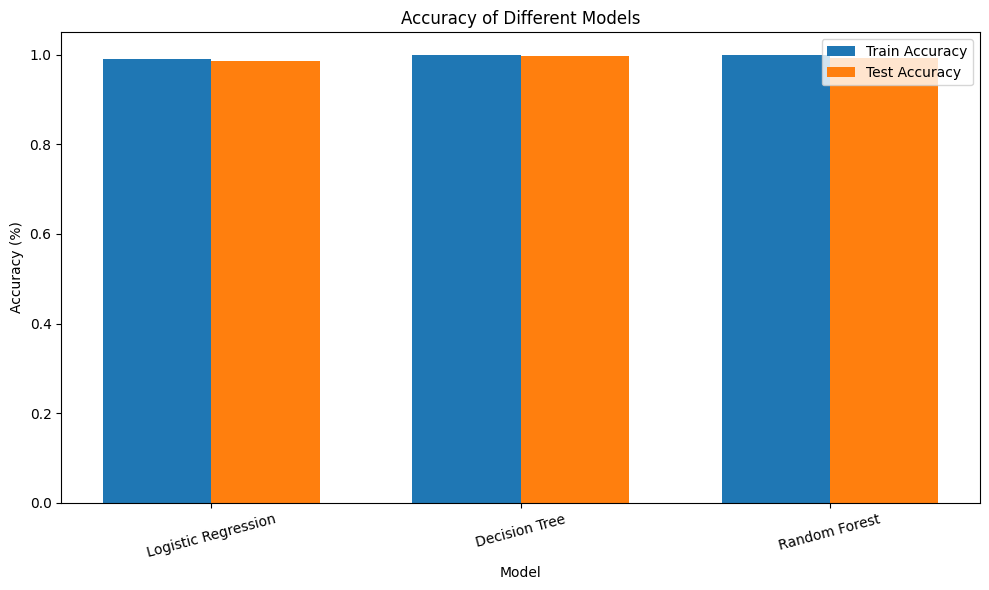

In [71]:
# Plotting accuracy comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = range(len(df))

plt.bar(index, df['Train Accuracy (%)'], bar_width, label='Train Accuracy')
plt.bar([i + bar_width for i in index], df['Test Accuracy (%)'], bar_width, label='Test Accuracy')

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy of Different Models')
plt.xticks([i + bar_width / 2 for i in index], df['Model'], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


##Confusion Matrix

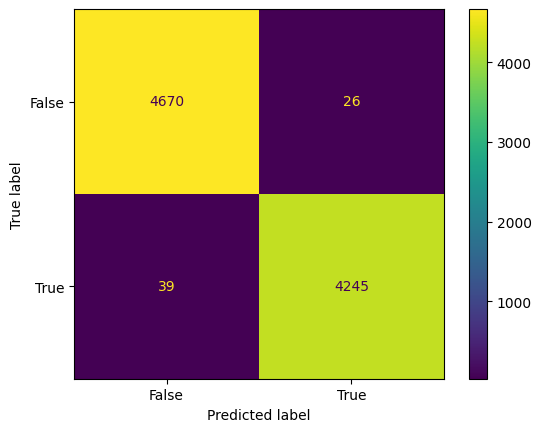

In [75]:
# Confusion matrix of Results from Decision Tree classification
from sklearn import metrics
cm = metrics.confusion_matrix(Y_test, rfc.predict(xv_test))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

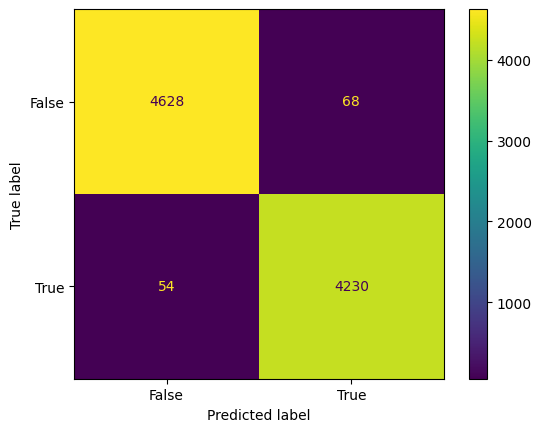

In [76]:
from sklearn import metrics
cm = metrics.confusion_matrix(Y_test, LR.predict(xv_test))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

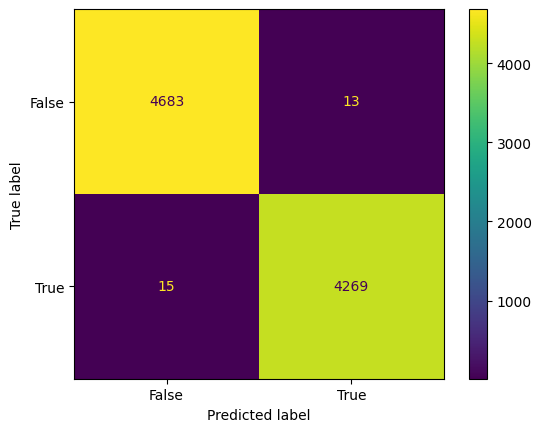

In [77]:
from sklearn import metrics
cm = metrics.confusion_matrix(Y_test, DTC.predict(xv_test))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

##Fake news detection System

In [78]:
def output_label(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

In [80]:
def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test['text']
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DTC = DTC.predict(new_xv_test)
    pred_rfc = rfc.predict(new_xv_test)
    return print("\n\nLR Prediction: {} \nDTC Prediction: {} \nRFC Prediction: {}".format(output_label(pred_LR[0]),
                                                                                             output_label(pred_DTC[0]),
                                                                                             output_label(pred_rfc[0])))

In [88]:
news_article = str(input())

Tensions between India and Pakistan have escalated into active military conflict, with both nations conducting airstrikes and missile attacks along the disputed Kashmir border. The violence follows a terrorist attack in Indian-administered Kashmir on April 22, which killed 28 civilians, mostly Hindu tourists. India launched "Operation Sindoor" in retaliation, targeting militant groups in Pakistan, while Pakistan claims to have downed several Indian aircraft and launched counterattacks. Both sides report civilian casualties, and the situation remains volatile


In [89]:
manual_testing(news_article)



LR Prediction: Not A Fake News 
DTC Prediction: Fake News 
RFC Prediction: Not A Fake News
